<a href="https://colab.research.google.com/github/Diyol6163/Legal_Assistant_RAG/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
data = pd.read_csv('./Micro_Climate.csv')

In [ ]:
# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(data.head())


First few rows of the dataset:
       EnqueuedTimeUtc deviceId  humidity  temparature  irTemparature
0  16/02/2023 13:41:57  290EC1B        83           14             10
1  16/02/2023 13:41:57  290EF53        83           14             12
2  16/02/2023 13:41:58  290F190        88           13             12
3  16/02/2023 13:41:59  290F39C        84           13             11
4  16/02/2023 13:41:59  290F362        89           12             11


In [ ]:
# Check for missing values
print("\nMissing values in the dataset:")
print(data.isnull().sum())

# Convert 'EnqueuedTimeUtc' column to datetime format
data['EnqueuedTimeUtc'] = pd.to_datetime(data['EnqueuedTimeUtc'])

# Drop any rows with missing values
data.dropna(inplace=True)

# Display information about the dataset after preprocessing
print("\nInformation about the dataset after preprocessing:")
print(data.info())



Missing values in the dataset:
EnqueuedTimeUtc    0
deviceId           0
humidity           0
temparature        0
irTemparature      0
dtype: int64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_7572\3143878956.py:6: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['EnqueuedTimeUtc'] = pd.to_datetime(data['EnqueuedTimeUtc'])



Information about the dataset after preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371079 entries, 0 to 371078
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   EnqueuedTimeUtc  371079 non-null  datetime64[ns]
 1   deviceId         371079 non-null  object        
 2   humidity         371079 non-null  int64         
 3   temparature      371079 non-null  int64         
 4   irTemparature    371079 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 14.2+ MB
None


In [ ]:
def detect_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers

# Iterate over numerical columns to detect outliers
outliers_dict = {}
for column in data.select_dtypes(include=['float64', 'int64']):
    outliers_dict[column] = detect_outliers(data[column])

# Display outliers for each numerical column
for column, outliers in outliers_dict.items():
    if not outliers.empty:
        print(f"Outliers in column '{column}':")
        print(outliers)

Outliers in column 'humidity':
12099     43
12140     41
12142     42
12154     42
12160     42
          ..
370546     0
370549     0
370552     0
370555     0
370558     0
Name: humidity, Length: 46150, dtype: int64
Outliers in column 'temparature':
12202     26
12204     26
12214     27
12216     26
12226     28
          ..
168397    -3
168407    -3
168418    -3
168429    -3
362476   -40
Name: temparature, Length: 4146, dtype: int64
Outliers in column 'irTemparature':
28146    -10
28157     -8
28168     -8
28177     -8
28188     -7
          ..
370546    58
370549    58
370552    58
370555    58
370558    58
Name: irTemparature, Length: 36513, dtype: int64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_7572\2202919908.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


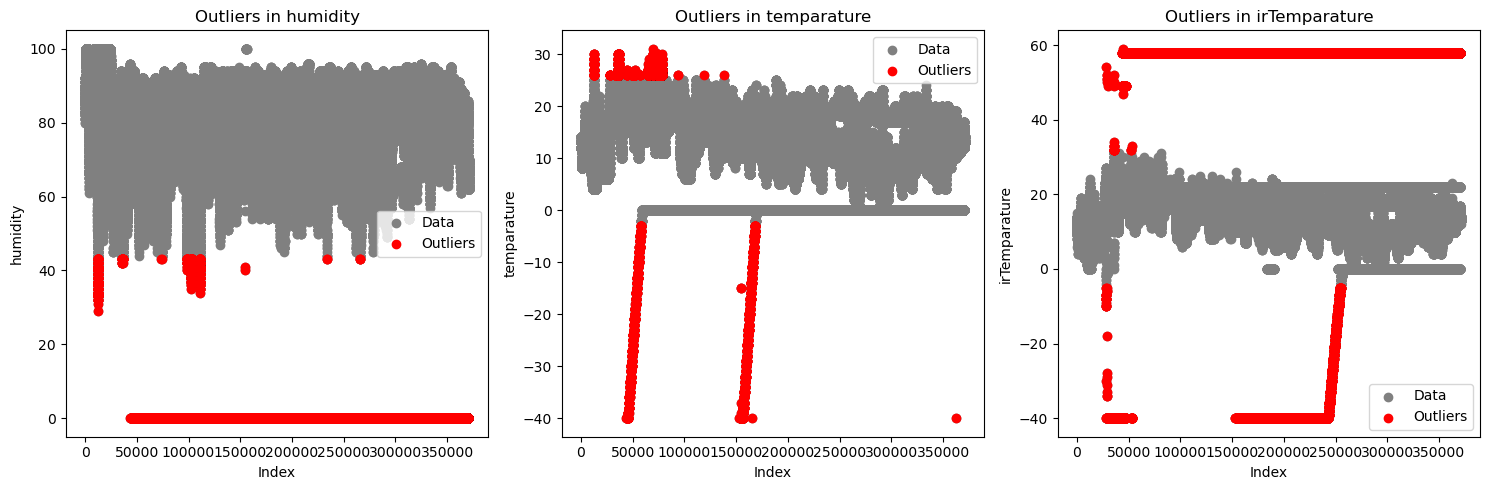

In [ ]:
import matplotlib.pyplot as plt

# Define a function to detect outliers using the IQR method
def detect_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers

# Iterate over numerical columns to detect outliers
outliers_dict = {}
for column in data.select_dtypes(include=['float64', 'int64']):
    outliers_dict[column] = detect_outliers(data[column])

# Plot outliers using scatter plots
fig, axes = plt.subplots(nrows=1, ncols=len(outliers_dict), figsize=(15, 5))

for i, (column, outliers) in enumerate(outliers_dict.items()):
    ax = axes[i] if len(outliers_dict) > 1 else axes
    ax.scatter(data.index, data[column], color='gray', label='Data')
    ax.scatter(outliers.index, outliers.values, color='red', label='Outliers')
    ax.set_title(f'Outliers in {column}')
    ax.set_xlabel('Index')
    ax.set_ylabel(column)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
 #Summary statistics for numerical columns
print(data.describe())


                     EnqueuedTimeUtc       humidity    temparature  \
count                         371079  371079.000000  371079.000000   
mean   2023-10-20 04:37:26.731698944      70.233212      10.984189   
min              2023-02-16 13:41:57       0.000000       0.000000   
25%              2023-10-13 02:54:10      69.000000       8.000000   
50%              2023-11-05 18:22:24      80.000000      11.000000   
75%              2023-11-28 11:18:08      86.000000      15.000000   
max              2023-12-22 09:25:57     100.000000      31.000000   
std                              NaN      27.817407       6.000229   

       irTemparature        cluster  
count  371079.000000  371079.000000  
mean       15.706472       0.172529  
min         0.000000       0.000000  
25%         9.000000       0.000000  
50%        12.000000       0.000000  
75%        18.000000       0.000000  
max        59.000000       2.000000  
std        13.041134       0.493066  


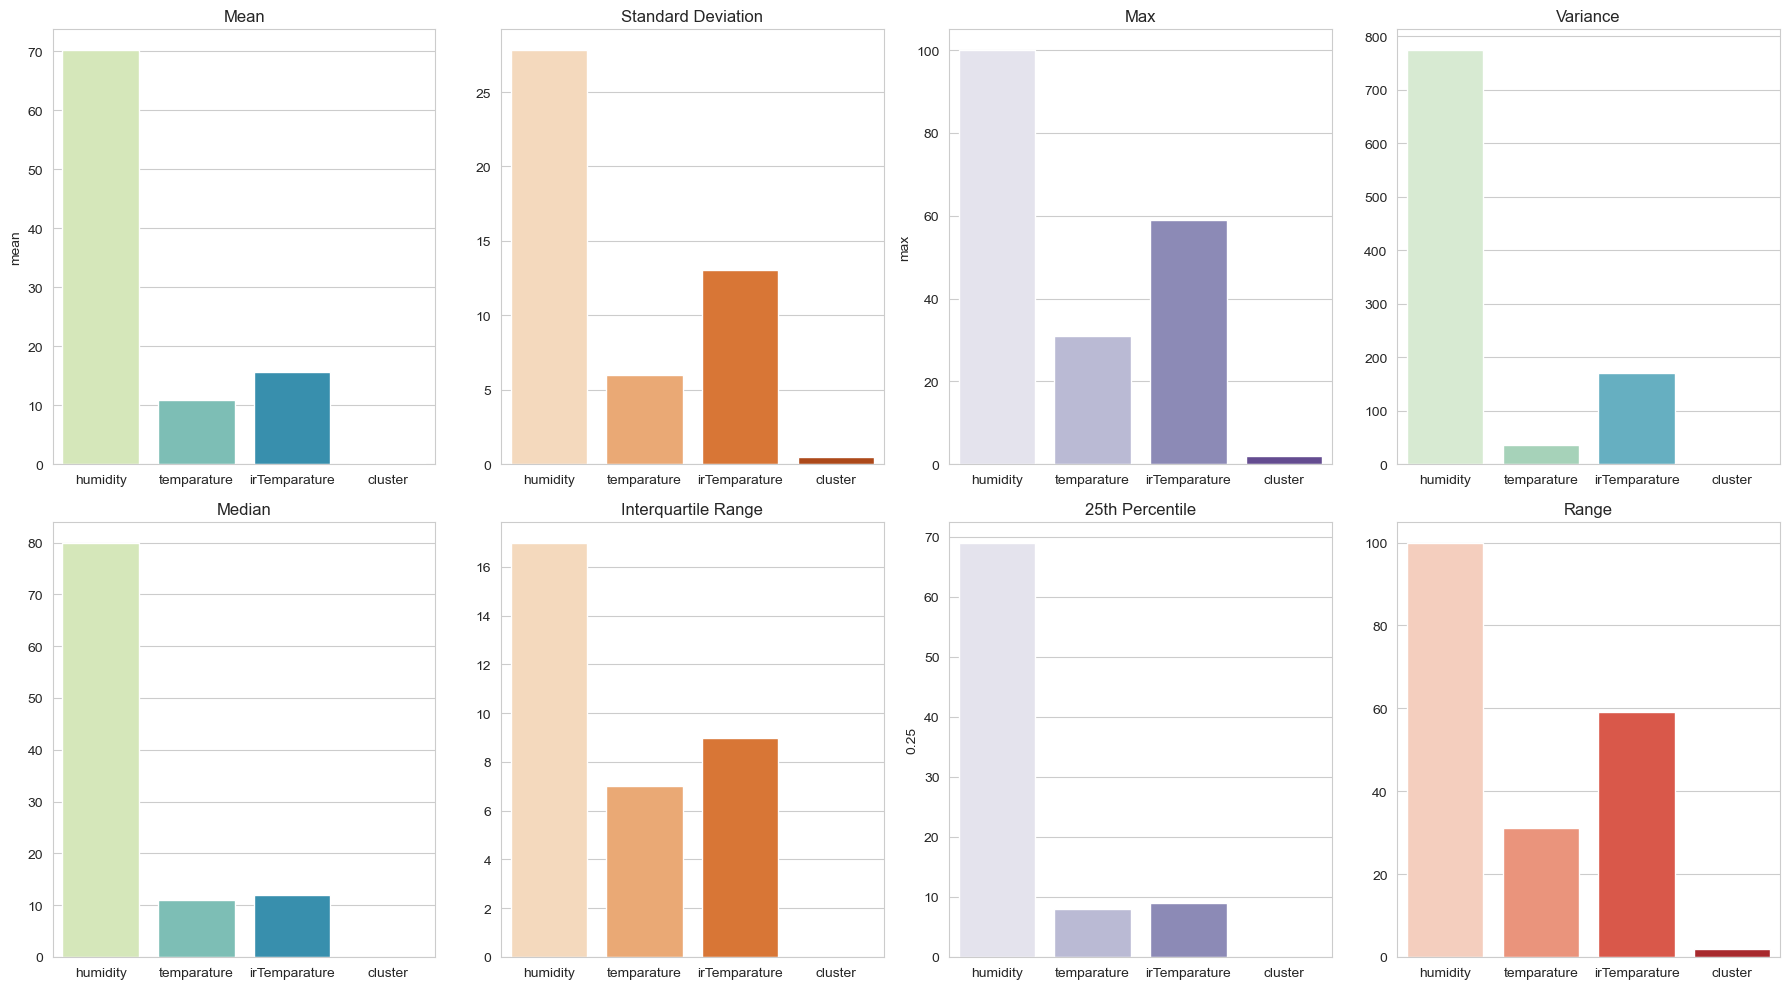

In [ ]:
# Exclude non-numeric columns from summary statistics
numeric_columns = data.select_dtypes(include=['number'])

# Compute summary statistics
summary_stats = numeric_columns.describe()

# Calculate median
median = numeric_columns.median()

# Calculate interquartile range (IQR)
q1 = numeric_columns.quantile(0.25)
q3 = numeric_columns.quantile(0.75)
iqr = q3 - q1

# Calculate variance
variance = numeric_columns.var()

# Calculate standard deviation
std_deviation = numeric_columns.std()

# Calculate range
data_range = numeric_columns.max() - numeric_columns.min()

# Plot summary statistics
plt.figure(figsize=(18, 10))

# Mean
plt.subplot(2, 4, 1)
sns.barplot(x=summary_stats.columns, y=summary_stats.loc['mean'], palette="YlGnBu")
plt.title('Mean')

# Standard Deviation
plt.subplot(2, 4, 2)
sns.barplot(x=std_deviation.index, y=std_deviation, palette="Oranges")
plt.title('Standard Deviation')

# Max
plt.subplot(2, 4, 3)
sns.barplot(x=summary_stats.columns, y=summary_stats.loc['max'], palette="Purples")
plt.title('Max')

# Variance
plt.subplot(2, 4, 4)
sns.barplot(x=variance.index, y=variance, palette="GnBu")
plt.title('Variance')

# Median
plt.subplot(2, 4, 5)
sns.barplot(x=median.index, y=median, palette="YlGnBu")
plt.title('Median')

# Interquartile Range
plt.subplot(2, 4, 6)
sns.barplot(x=iqr.index, y=iqr, palette="Oranges")
plt.title('Interquartile Range')

# 25th Percentile (Q1)
plt.subplot(2, 4, 7)
sns.barplot(x=q1.index, y=q1, palette="Purples")
plt.title('25th Percentile')

# Range
plt.subplot(2, 4, 8)
sns.barplot(x=data_range.index, y=data_range, palette="Reds")
plt.title('Range')

plt.tight_layout()
plt.show()


In [ ]:
# Ensure values are positive
data['temparature'] = data['temparature'].apply(lambda x: max(0, x))
data['humidity'] = data['humidity'].apply(lambda x: max(0, x))
data['irTemparature'] = data['irTemparature'].apply(lambda x: max(0, x))

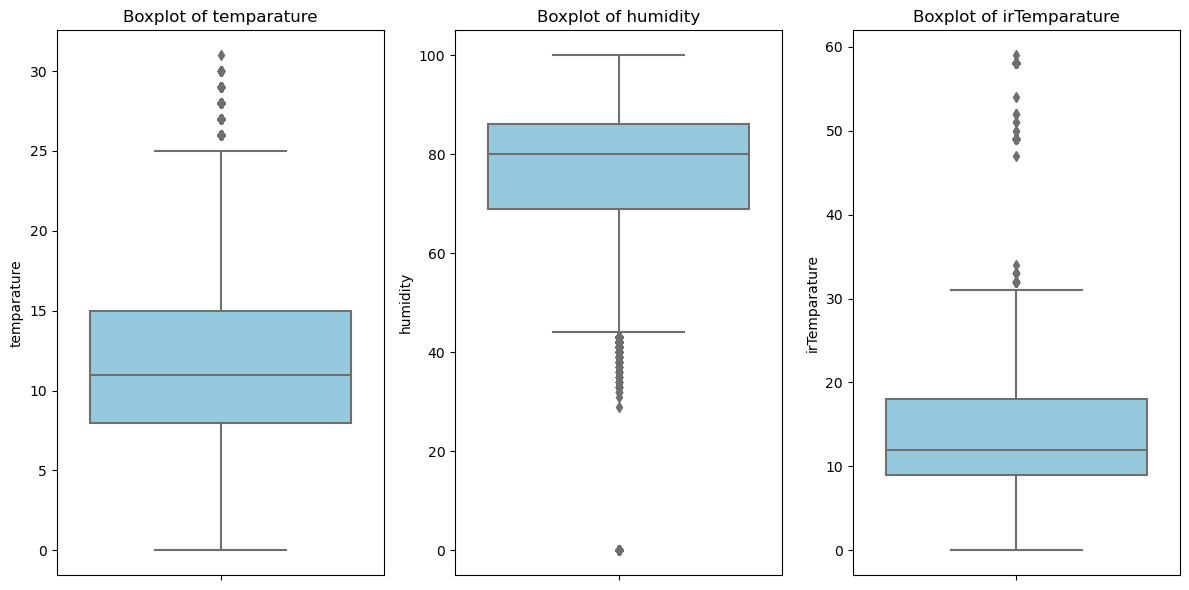

In [ ]:
# Select the columns of interest
columns_of_interest = ['temparature', 'humidity', 'irTemparature']

# Create box plots for each column
plt.figure(figsize=(12, 6))
for i, column in enumerate(columns_of_interest, 1):
    plt.subplot(1, len(columns_of_interest), i)
    sns.boxplot(y=data[column], color='skyblue')
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
plt.tight_layout()
plt.show()


Correlation Matrix:
               temparature  humidity  irTemparature
temparature       1.000000  0.507877      -0.173708
humidity          0.507877  1.000000      -0.532591
irTemparature    -0.173708 -0.532591       1.000000


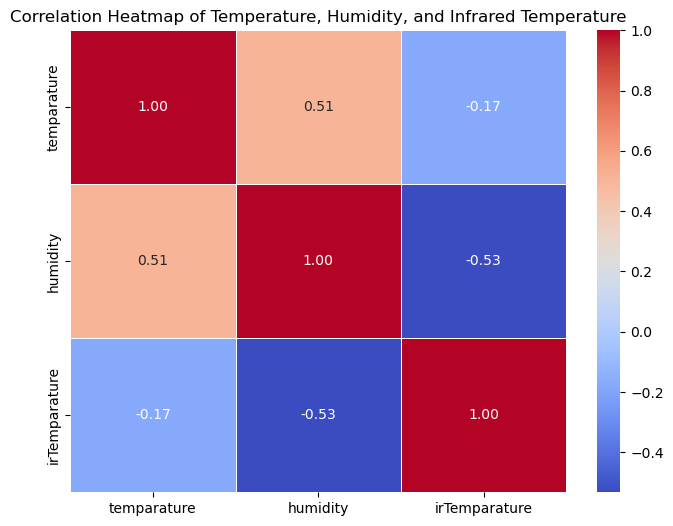

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


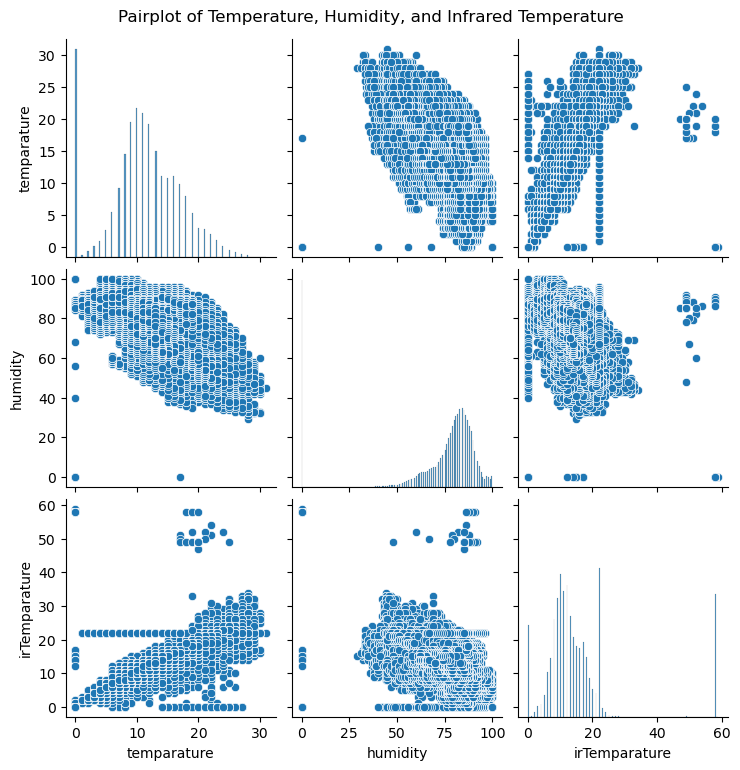

In [ ]:
# Selecting the columns of interest
columns_of_interest = ['temparature', 'humidity', 'irTemparature']

# Compute correlation matrix
correlation_matrix = data[columns_of_interest].corr()

# Display correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

columns_of_interest = ['temparature', 'humidity', 'irTemparature']

# Compute correlation coefficients
correlation_matrix = data[columns_of_interest].corr()

# Plotting correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Temperature, Humidity, and Infrared Temperature')
plt.show()

# Regression modeling (example using Seaborn)
sns.pairplot(data[columns_of_interest])
plt.suptitle('Pairplot of Temperature, Humidity, and Infrared Temperature', y=1.02)
plt.show()

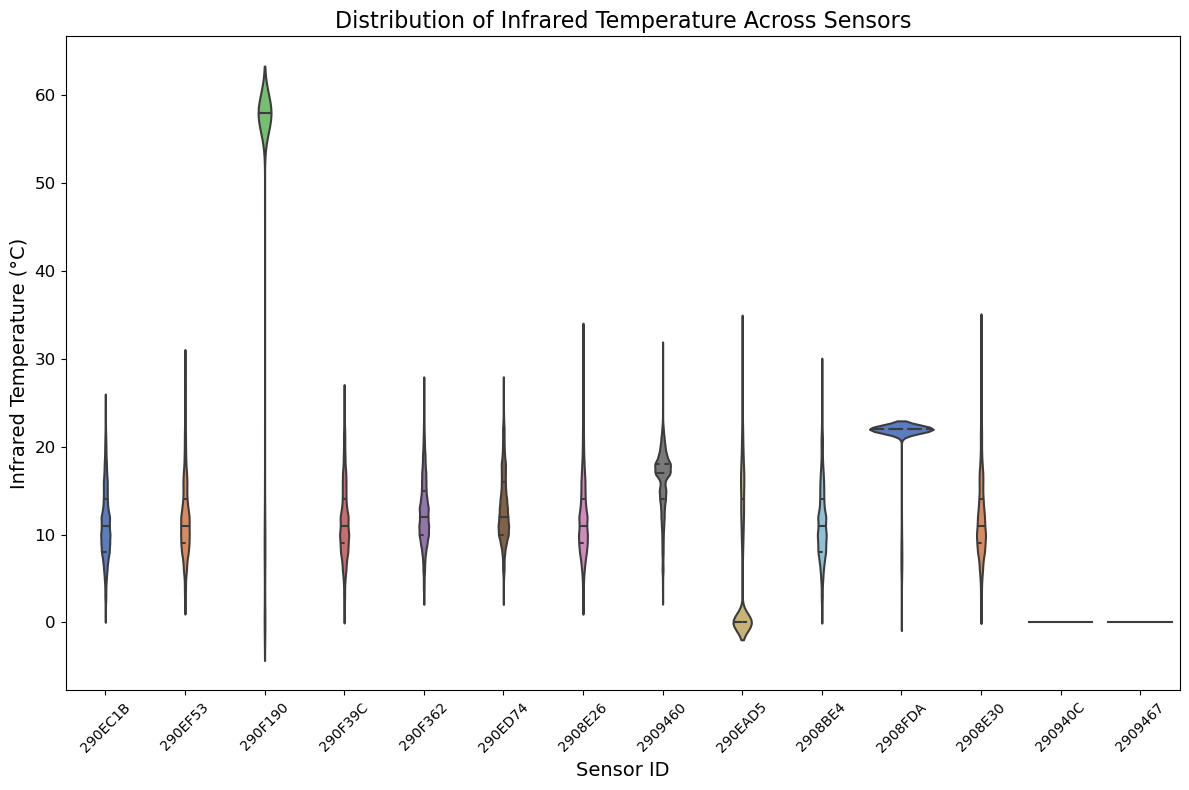

In [ ]:
plt.figure(figsize=(12, 8))
sns.violinplot(data=data, x='deviceId', y='irTemparature', palette='muted', inner='quartile')
plt.title('Distribution of Infrared Temperature Across Sensors', fontsize=16)
plt.xlabel('Sensor ID', fontsize=14)
plt.ylabel('Infrared Temperature (°C)', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


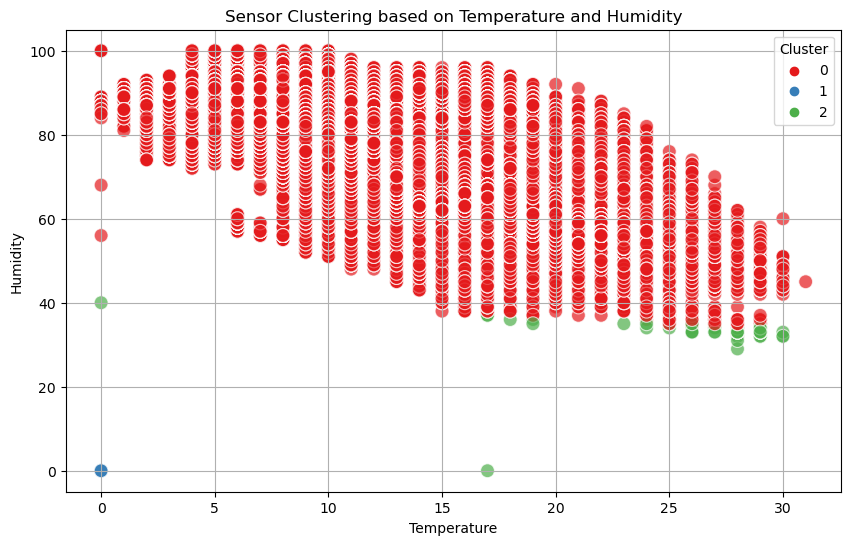

In [ ]:
from sklearn.cluster import KMeans

# Corrected column names
columns_of_interest = ['temparature', 'humidity', 'irTemparature']

# Extracting the data for clustering
X = data[columns_of_interest]

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3)  # You can adjust the number of clusters as needed
kmeans.fit(X)
data['cluster'] = kmeans.labels_

# Visualizing the clusters using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='temparature', y='humidity', hue='cluster', palette='Set1', legend='full', s=100, alpha=0.7)
plt.title('Sensor Clustering based on Temperature and Humidity')
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.legend(title='Cluster', loc='upper right')
plt.grid(True)
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


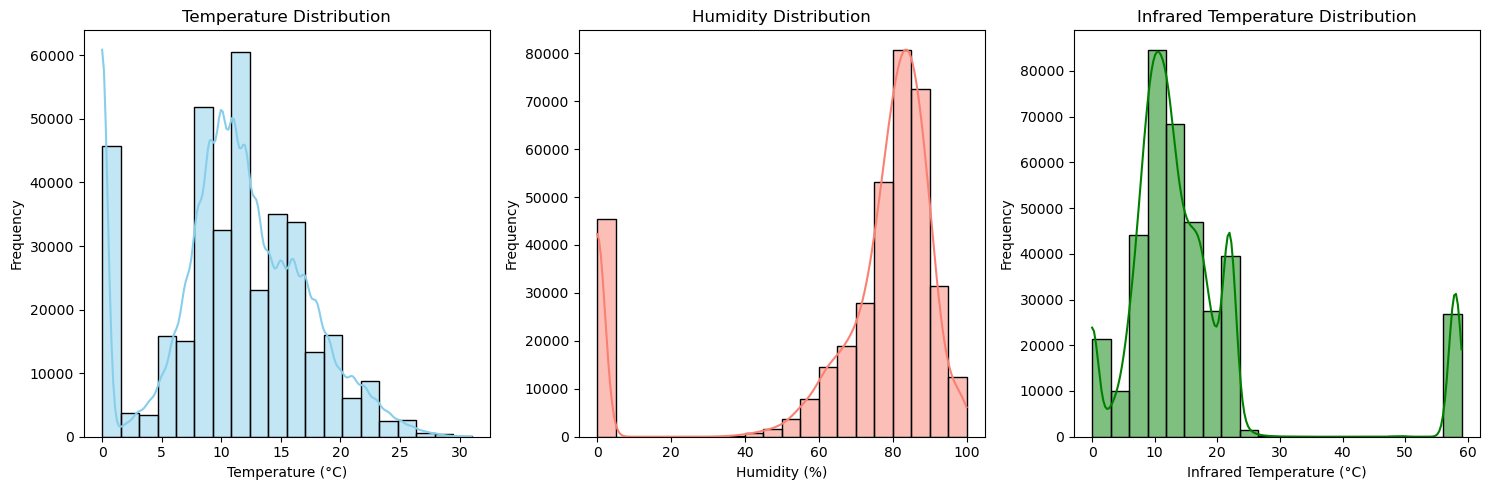

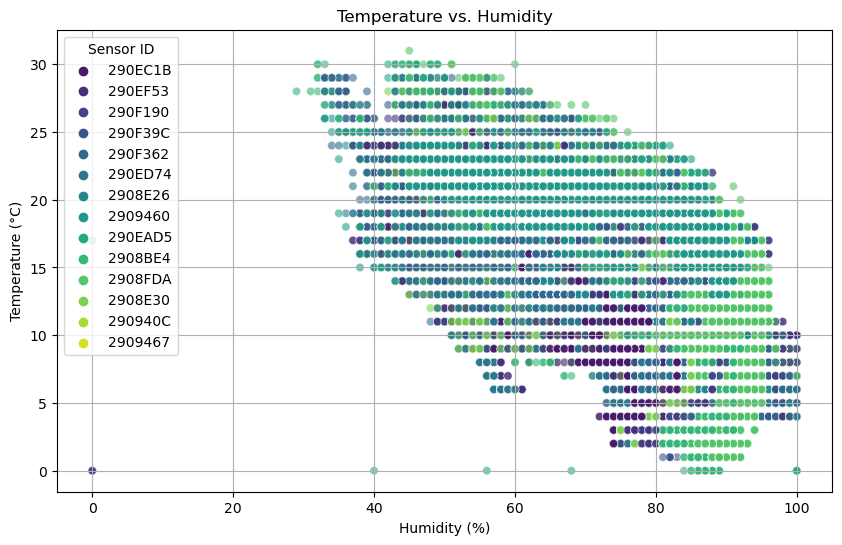

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Plot histogram of temperature, humidity, and infrared temperature
plt.figure(figsize=(15, 5))

# Subplot for temperature
plt.subplot(1, 3, 1)
sns.histplot(data['temparature'], bins=20, kde=True, color='skyblue')
plt.title('Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')

# Subplot for humidity
plt.subplot(1, 3, 2)
sns.histplot(data['humidity'], bins=20, kde=True, color='salmon')
plt.title('Humidity Distribution')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')

# Subplot for infrared temperature
plt.subplot(1, 3, 3)
sns.histplot(data['irTemparature'], bins=20, kde=True, color='green')
plt.title('Infrared Temperature Distribution')
plt.xlabel('Infrared Temperature (°C)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Step 2: Plot scatter plot of temperature against humidity with color differentiation for sensors
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='humidity', y='temparature', hue='deviceId', palette='viridis', alpha=0.6)
plt.title('Temperature vs. Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('Temperature (°C)')
plt.legend(title='Sensor ID', loc='best')
plt.grid(True)
plt.show()




In [ ]:

# Create scatter plots
plt.figure(figsize=(12, 6))

# Temperature vs. Humidity
plt.subplot(1, 3, 1)
sns.scatterplot(data=data, x='temparature', y='humidity')
plt.title('Temperature vs. Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')

# Temperature vs. Infrared Temperature
plt.subplot(1, 3, 2)
sns.scatterplot(data=data, x='temparature', y='irTemparature')
plt.title('Temperature vs. Infrared Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Infrared Temperature (°C)')

# Humidity vs. Infrared Temperature
plt.subplot(1, 3, 3)
sns.scatterplot(data=data, x='humidity', y='irTemparature')
plt.title('Humidity vs. Infrared Temperature')
plt.xlabel('Humidity (%)')
plt.ylabel('Infrared Temperature (°C)')

plt.tight_layout()
plt.show()


In [ ]:
#RESERACH QESTION1 : IDENTIFYING IS THERE ANY CORRELIATION BETWEEN AIR TEMPERATURE AND HUMIDITY
# ALSO TRY ING TO FIND THE TREND  TROUGH THIS WE CAN DERTIME HOW MUCH AIR TEMPERTURE AFFECTS HUMIDITY LEVELS

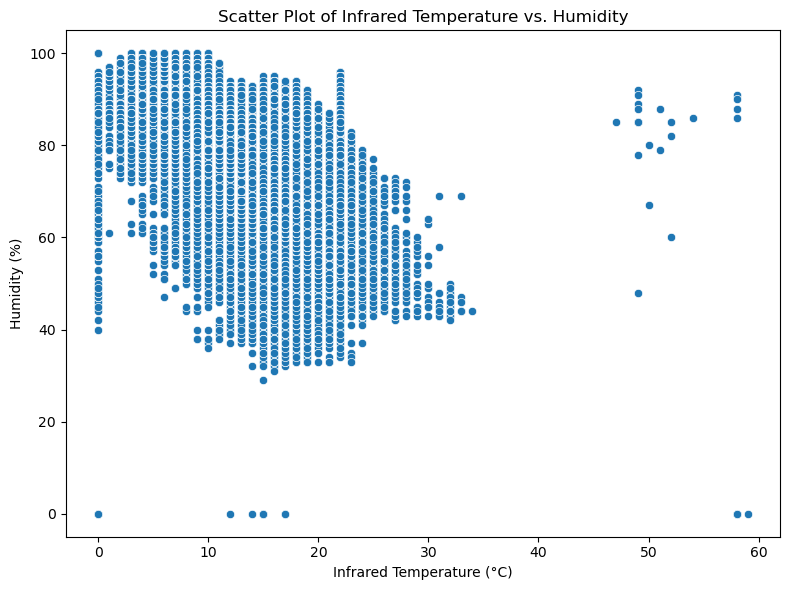

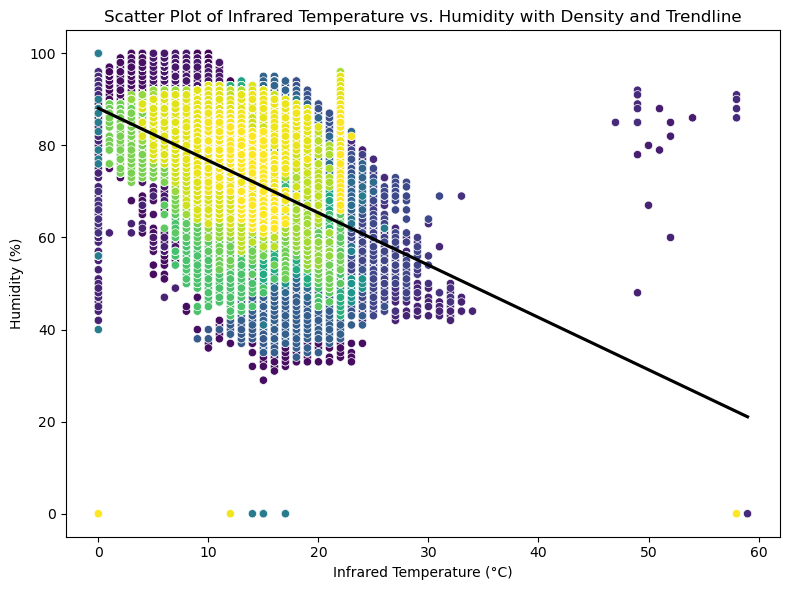

Correlation Coefficient (Infrared Temperature vs. Humidity): -0.5325909584438904
Average Humidity by Infrared Temperature Groups:
 irTemparature
(-0.059, 11.8]    73.376205
(11.8, 23.6]      77.914588
(23.6, 35.4]      56.476862
(35.4, 47.2]      85.000000
(47.2, 59.0]       0.326465
Name: humidity, dtype: float64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_7572\180434275.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_humidity_by_temperature = data.groupby(temperature_groups)['humidity'].mean()  # Corrected column names


In [ ]:
# Visualize the distribution
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='irTemparature', y='humidity')
plt.title('Scatter Plot of Infrared Temperature vs. Humidity')
plt.xlabel('Infrared Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.tight_layout()
plt.show()

# Refine the visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='irTemparature', y='humidity', hue=data.index, palette='viridis', legend=False)
sns.regplot(data=data, x='irTemparature', y='humidity', scatter=False, color='black')
plt.title('Scatter Plot of Infrared Temperature vs. Humidity with Density and Trendline')
plt.xlabel('Infrared Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.tight_layout()
plt.show()

# Calculate the correlation coefficient
correlation_coefficient = data['irTemparature'].corr(data['humidity'])  # Corrected column names
print("Correlation Coefficient (Infrared Temperature vs. Humidity):", correlation_coefficient)

# Group and analyze
temperature_groups = pd.cut(data['irTemparature'], bins=5)
average_humidity_by_temperature = data.groupby(temperature_groups)['humidity'].mean()  # Corrected column names
print("Average Humidity by Infrared Temperature Groups:\n", average_humidity_by_temperature)



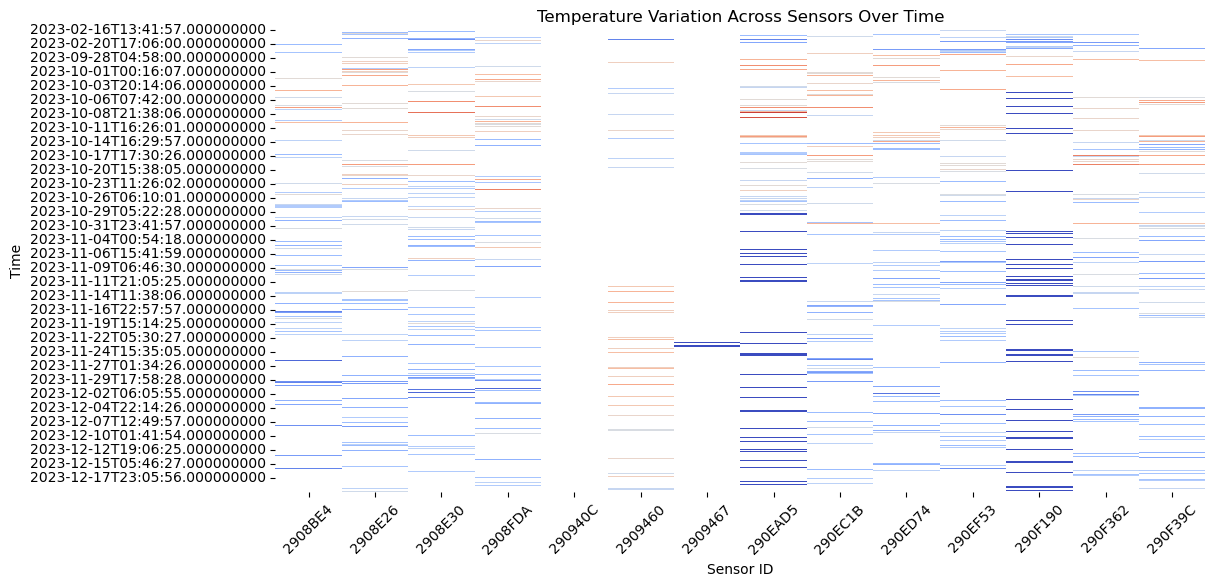

In [ ]:
# Research Question 3: Visualizing sensor data without anomaly detection
plt.figure(figsize=(12, 6))
sns.heatmap(data.pivot_table(index='EnqueuedTimeUtc', columns='deviceId', values='temparature'), cmap='coolwarm', cbar=False)
plt.title('Temperature Variation Across Sensors Over Time')
plt.xlabel('Sensor ID')
plt.ylabel('Time')
plt.xticks(rotation=45)
plt.show()

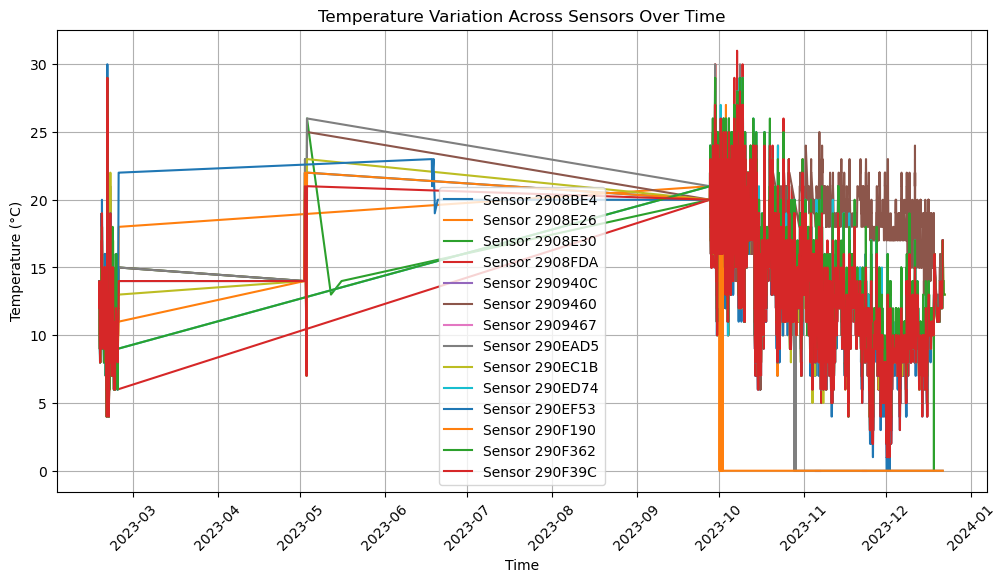

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming data is your DataFrame containing the sensor data

# Set the figure size
plt.figure(figsize=(12, 6))

# Plot the sensor data for each device
for device_id, device_data in data.groupby('deviceId'):
    plt.plot(device_data['EnqueuedTimeUtc'], device_data['temparature'], label=f'Sensor {device_id}')

# Add labels and title
plt.title('Temperature Variation Across Sensors Over Time')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Show plot
plt.show()


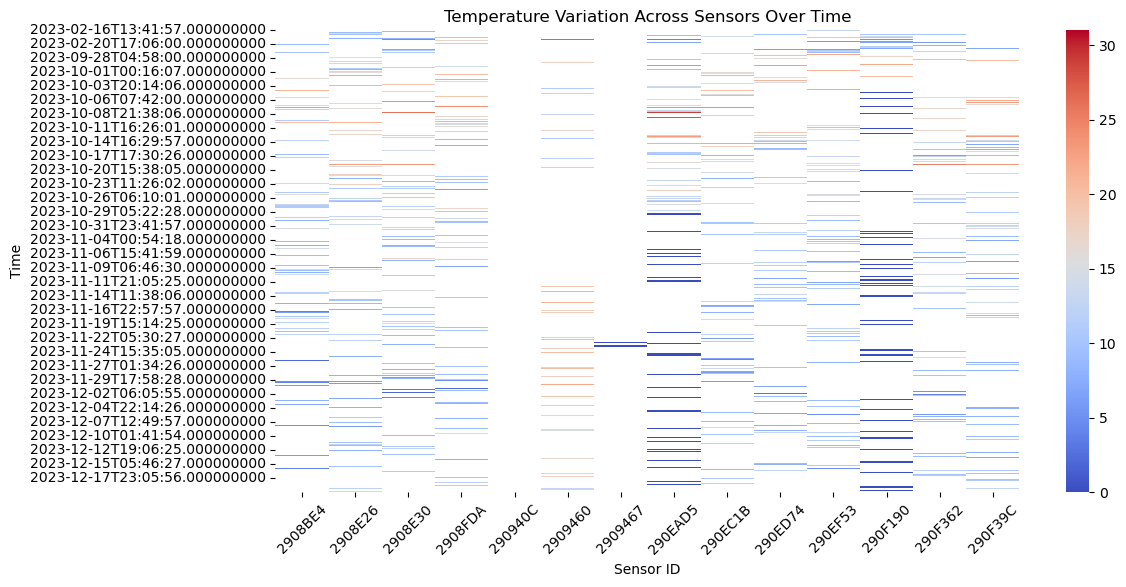

In [ ]:
# Assuming data is your DataFrame containing the sensor data

# Pivot the data
pivot_data = data.pivot_table(index='EnqueuedTimeUtc', columns='deviceId', values='temparature', aggfunc='mean')

# Create a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_data, cmap='coolwarm', cbar=True)

# Add labels and title
plt.title('Temperature Variation Across Sensors Over Time')
plt.xlabel('Sensor ID')
plt.ylabel('Time')
plt.xticks(rotation=45)

# Show plot
plt.show()



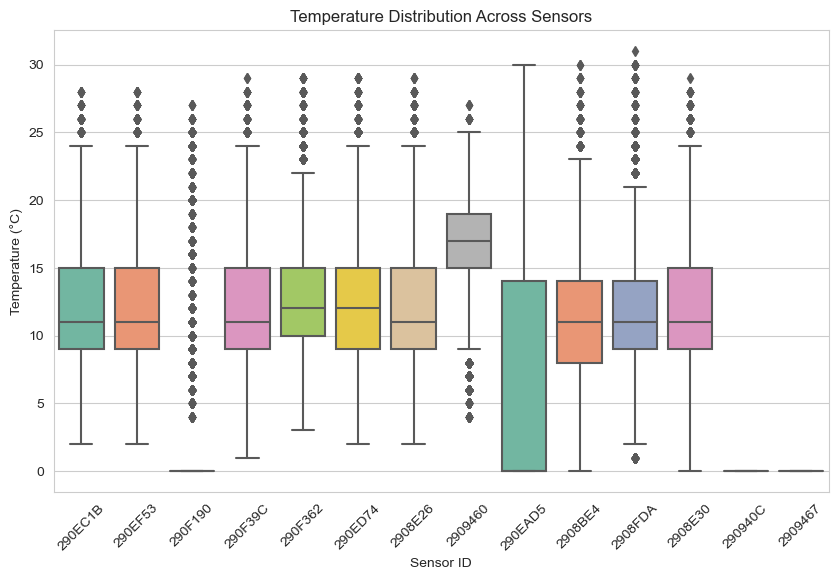

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a box plot or violin plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='deviceId', y='temparature', palette='Set2')
plt.title('Temperature Distribution Across Sensors')
plt.xlabel('Sensor ID')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.show()



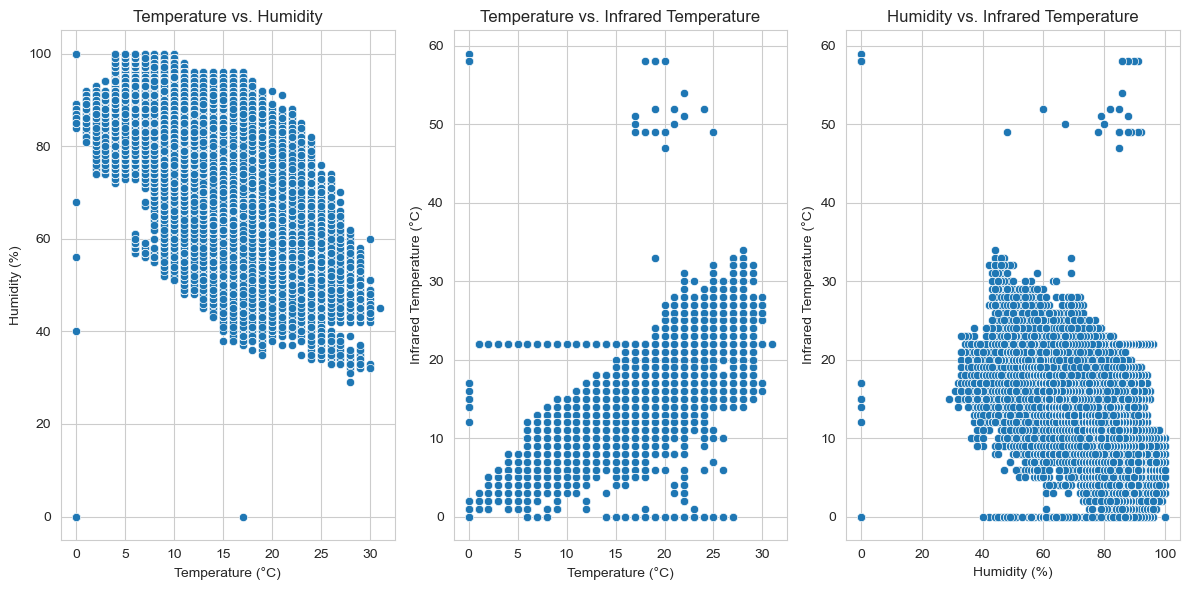

In [ ]:
# Create scatter plots
plt.figure(figsize=(12, 6))

# Temperature vs. Humidity
plt.subplot(1, 3, 1)
sns.scatterplot(data=data, x='temparature', y='humidity')
plt.title('Temperature vs. Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')

# Temperature vs. Infrared Temperature
plt.subplot(1, 3, 2)
sns.scatterplot(data=data, x='temparature', y='irTemparature')
plt.title('Temperature vs. Infrared Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Infrared Temperature (°C)')

# Humidity vs. Infrared Temperature
plt.subplot(1, 3, 3)
sns.scatterplot(data=data, x='humidity', y='irTemparature')
plt.title('Humidity vs. Infrared Temperature')
plt.xlabel('Humidity (%)')
plt.ylabel('Infrared Temperature (°C)')

plt.tight_layout()
plt.show()


In [ ]:
#Create a scatter plot to visualize the correlation between temperature and infrared temperature
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='temparature', y='irTemparature', hue='deviceId')
plt.title('Temperature vs. Infrared Temperature Across Sensors')
plt.xlabel('Temperature (°C)')
plt.ylabel('Infrared Temperature (°C)')
plt.legend(title='Sensor ID')
plt.show()

In [ ]:
# Display the column names in the dataset
print(data.columns)


Index(['EnqueuedTimeUtc', 'deviceId', 'humidity', 'temparature',
       'irTemparature', 'cluster'],
      dtype='object')


In [ ]:
#What are the diurnal patterns of temperature and humidity within the strawberry greenhouse, and how do these patterns differ across sensors?"

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

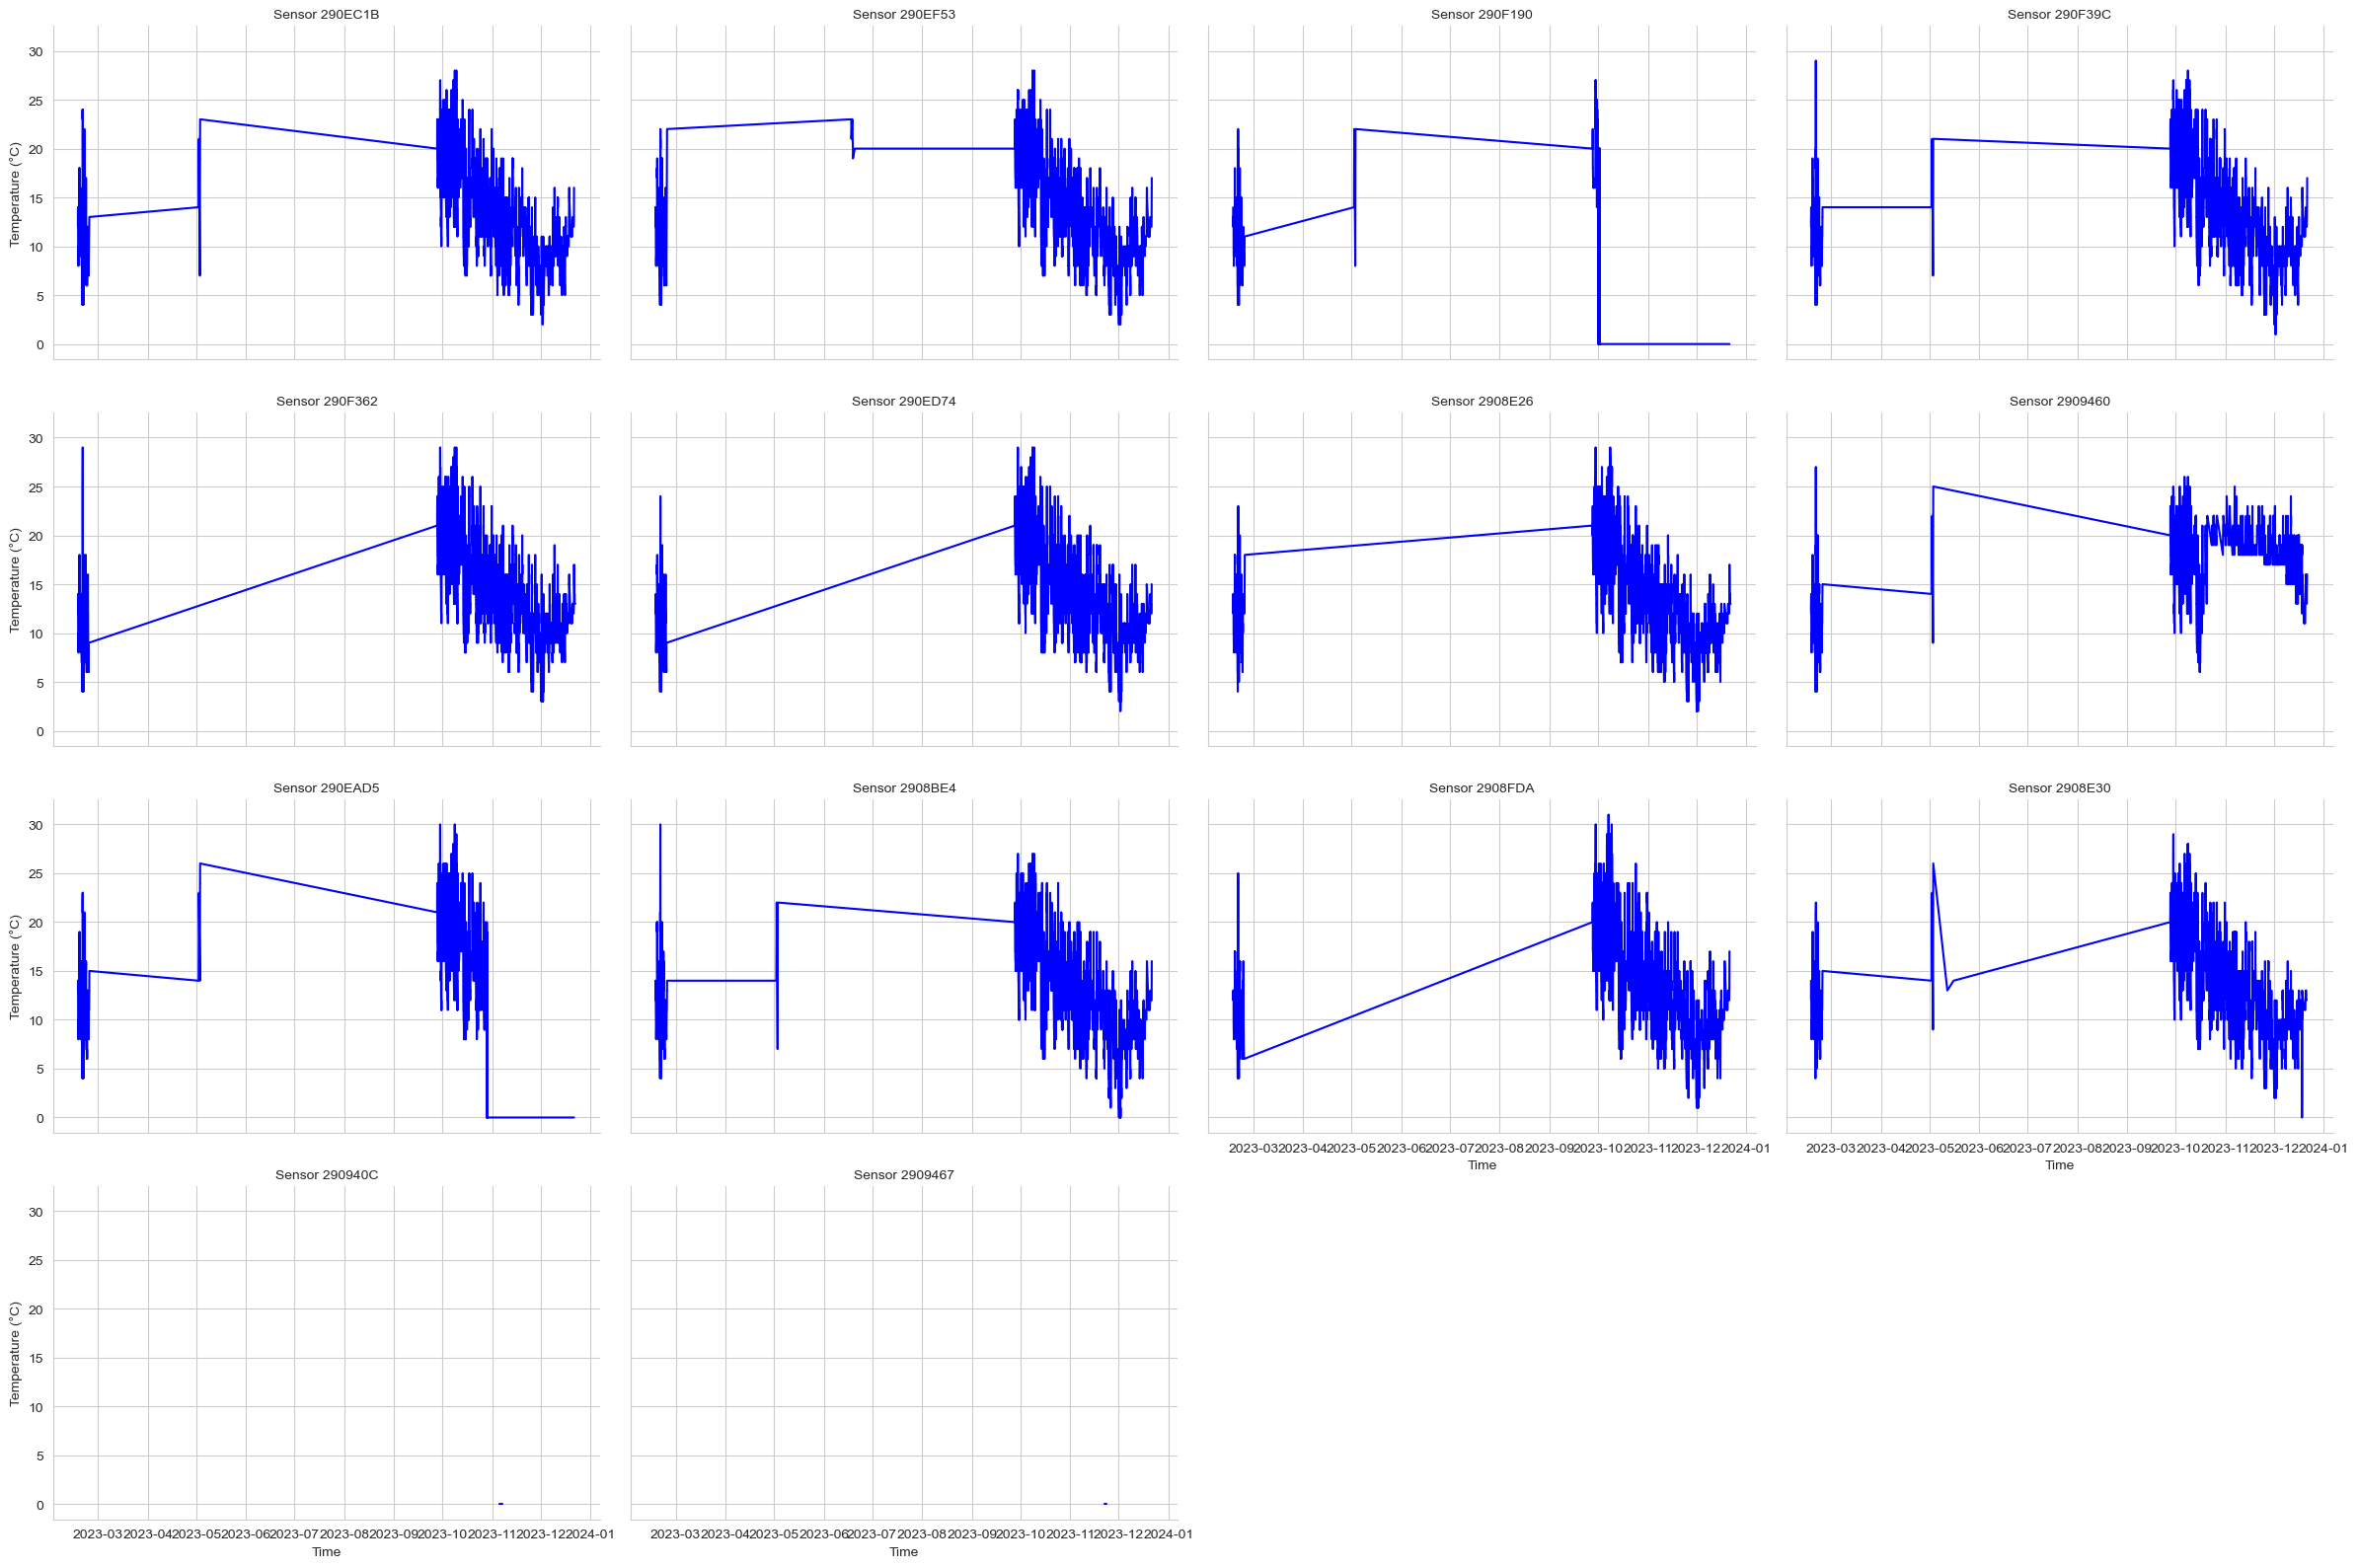

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for seaborn
sns.set_style("whitegrid")

# Create a facet grid for temperature and humidity
g = sns.FacetGrid(data=data, col="deviceId", col_wrap=4, height=4, aspect=1.5)
g.map(sns.lineplot, "EnqueuedTimeUtc", "temparature", color="blue")
g.set_axis_labels("Time", "Temperature (°C)")
g.set_titles("Sensor {col_name}")

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# Create a facet grid for humidity
g = sns.FacetGrid(data=data, col="deviceId", col_wrap=4, height=4, aspect=1.5)
g.map(sns.lineplot, "EnqueuedTimeUtc", "humidity", color="green")
g.set_axis_labels("Time", "Humidity (%)")
g.set_titles("Sensor {col_name}")

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()



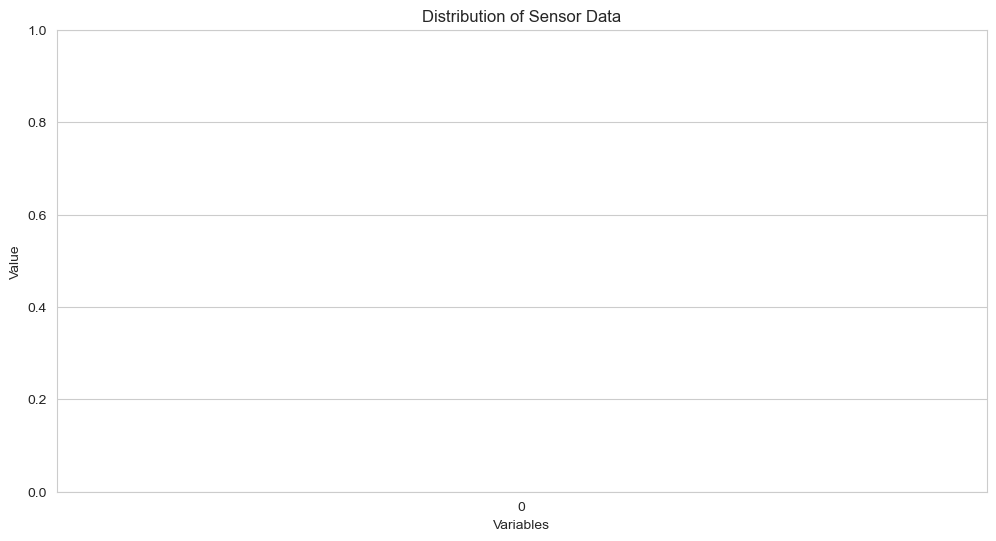